In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator


def load_image_sequences(file_paths, image_size=(64, 64), sequence_length=10):
    data = []
    labels = []
    for file_path in file_paths:
        with open(file_path, 'r') as f:
            lines = f.readlines()

        sequence = []
        for line in lines:
            img_path = line.strip()
            if not os.path.exists(img_path):
                print(f"[WARN] Image path does not exist: {img_path}")
                continue
            
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"[WARN] Could not load image: {img_path}")
                continue
            
            img = cv2.resize(img, image_size)
            sequence.append(img)

            if len(sequence) == sequence_length:
                data.append(np.array(sequence))
                labels.append(1 if "anomalies" in file_path else 0)
                sequence = sequence[1:]

    data = np.array(data).reshape(-1, sequence_length, image_size[0], image_size[1], 1)
    labels = np.array(labels)
    return data, labels


def augment_data(data, labels, target_size=800, image_size=(64, 64), sequence_length=10):
    augmented_data = []
    augmented_labels = []
    datagen = ImageDataGenerator(rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, zoom_range=0.2)


    anomaly_indices = np.where(labels == 1)[0]
    normal_indices = np.where(labels == 0)[0]


    for idx in anomaly_indices:
        sequence = data[idx]
        augmented_data.append(sequence) 
        augmented_labels.append(1)

        for _ in range((target_size - len(anomaly_indices)) // len(anomaly_indices) + 1):
            augmented_sequence = []
            for frame in sequence:
                frame = frame.reshape((1,) + frame.shape) 
                iterator = datagen.flow(frame, batch_size=1)  
                augmented_frame = next(iterator)[0]  
                augmented_sequence.append(augmented_frame.reshape(image_size + (1,)))

            augmented_data.append(np.array(augmented_sequence))
            augmented_labels.append(1)

            if len(augmented_data) >= target_size:
                break
        if len(augmented_data) >= target_size:
            break

    np.random.shuffle(normal_indices)
    downsampled_normal_indices = normal_indices[:target_size]

    for idx in downsampled_normal_indices:
        augmented_data.append(data[idx])
        augmented_labels.append(0)

    final_data = np.array(augmented_data)
    final_labels = np.array(augmented_labels)

    return final_data, final_labels


file_paths = ['/kaggle/working/normal.txt', '/kaggle/working/anomalies.txt']
data, labels = load_image_sequences(file_paths)
balanced_data, balanced_labels = augment_data(data, labels, target_size=800)

X_train, X_val, y_train, y_val = train_test_split(balanced_data, balanced_labels, test_size=0.2, random_state=42)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input

def create_lstm_cnn_model(sequence_length=10, image_size=(64, 64), channels=1):
    model = Sequential()

    model.add(TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'),
                              input_shape=(sequence_length, image_size[0], image_size[1], channels)))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Flatten()))

    model.add(LSTM(100, return_sequences=False))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    return model

model = create_lstm_cnn_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
              loss='binary_crossentropy', 
              metrics=['accuracy', tf.keras.metrics.Recall()])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_recall', patience=5, restore_best_weights=True, mode='max')

class CustomEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, target_accuracy=0.98):
        super(CustomEarlyStopping, self).__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        val_accuracy = logs.get('val_accuracy') 
        if val_accuracy is not None and val_accuracy >= self.target_accuracy:
            print(f"\n[INFO] Reached {self.target_accuracy * 100}% validation accuracy, stopping training...")
            self.model.stop_training = True

custom_early_stopping = CustomEarlyStopping(target_accuracy=0.98)

try:
    with tf.device('/GPU:0'):
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32,
                            callbacks=[early_stopping, custom_early_stopping])
except RuntimeError as e:
    print("[WARN] GPU is not available, training on CPU instead")
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32,
                        callbacks=[early_stopping, custom_early_stopping])


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.6342 - loss: 0.6463 - recall_3: 0.7900 - val_accuracy: 0.8250 - val_loss: 0.5405 - val_recall_3: 0.8713
Epoch 2/30
 2/40 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.5547 - loss: 0.6848 - recall_3: 0.7961

/opt/conda/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_recall` which is not available. Available metrics are: accuracy,loss,recall_3,val_accuracy,val_loss,val_recall_3
  current = self.get_monitor_value(logs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.6535 - loss: 0.6025 - recall_3: 0.8783 - val_accuracy: 0.8313 - val_loss: 0.5189 - val_recall_3: 0.9357
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.6749 - loss: 0.5854 - recall_3: 0.8757 - val_accuracy: 0.8375 - val_loss: 0.4931 - val_recall_3: 0.8947
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.6852 - loss: 0.5805 - recall_3: 0.8554 - val_accuracy: 0.8562 - val_loss: 0.4865 - val_recall_3: 0.9298
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.7229 - loss: 0.5387 - recall_3: 0.8644 - val_accuracy: 0.8687 - val_loss: 0.4540 - val_recall_3: 0.9532
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7640 - loss: 0.5128 - recall_3: 0.8791 - val_accuracy: 0.8750 - val_loss: 0.4375 - val_recall_3: 0.9825
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7645 - loss: 0.5054 - recall_3: 0.8736 - val_accuracy: 0.8781 - val_loss: 0.4205 - val_recall_3: 0.98

In [ ]:
y_pred_prob = model.predict(X_val)
threshold = 0.5
y_pred = (y_pred_prob > threshold).astype("int32")

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=1)
recall = recall_score(y_val, y_pred, zero_division=1)
f1 = f1_score(y_val, y_pred, zero_division=1)
auc = roc_auc_score(y_val, y_pred_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")


model.save('lstm_cnn_balanced_anomaly_detection_model.h5')

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Accuracy: 0.9844
Precision: 0.9716
Recall: 1.0000
F1 Score: 0.9856
AUC: 0.9999


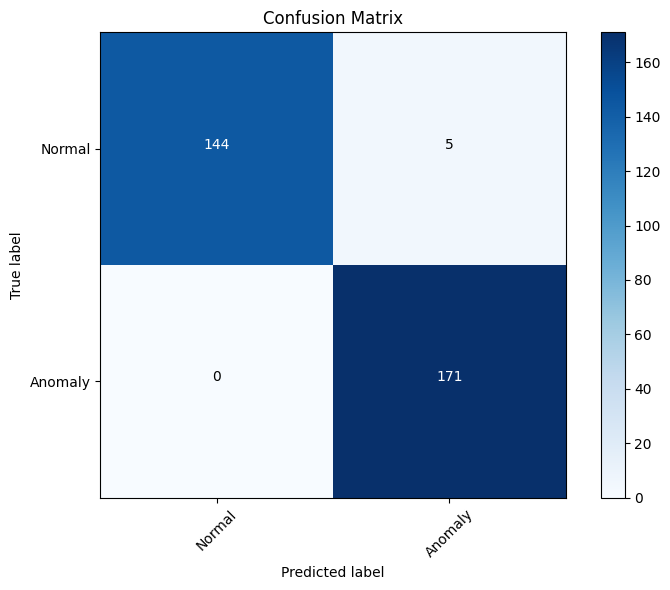

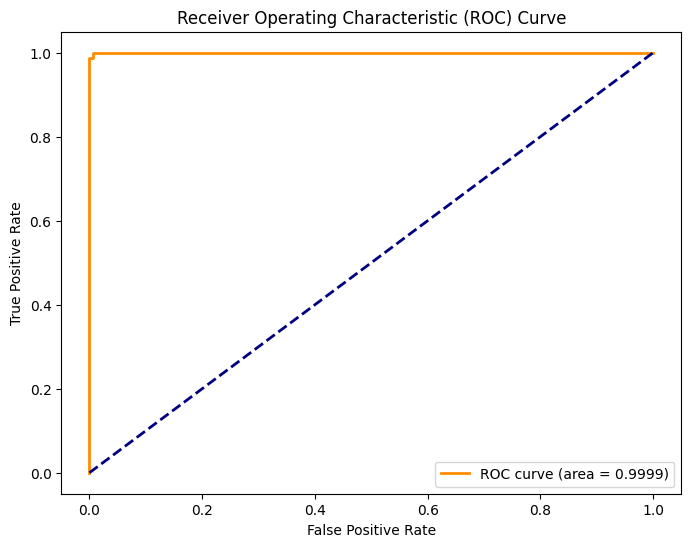

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, roc_curve, auc

conf_matrix = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Normal', 'Anomaly'], rotation=45)
plt.yticks(tick_marks, ['Normal', 'Anomaly'])

# Labeling the plot with counts from the confusion matrix
thresh = conf_matrix.max() / 2.
for i, j in np.ndindex(conf_matrix.shape):
    plt.text(j, i, format(conf_matrix[i, j], 'd'),
             horizontalalignment="center",
             color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
